In [7]:
print("hello")

hello


# Data Preprocessing Pipeline for Machine Learning
"""
This project demonstrates how raw data is transformed into a clean,
model-ready dataset using data preprocessing techniques.
Steps covered:
- Data exploration
- Data cleaning
- Missing value handling
- Categorical encoding
- Outlier detection
- Feature scaling
- Train-test split
"""

In [61]:
import pandas as pd
df = pd.read_csv(r"C:\Users\nl589\OneDrive\Documents\Desktop\Data Preprocessing\data\Titanic-Dataset.csv")
print(df)
df.head()

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [62]:
df.shape
#Gives size of tables (rows,cols) format

(891, 12)

In [63]:
df.info()
#cols info :
#numeric columns
#categorical columns
#missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [64]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Text(0.5, 1.0, 'Missing Data Visualization')

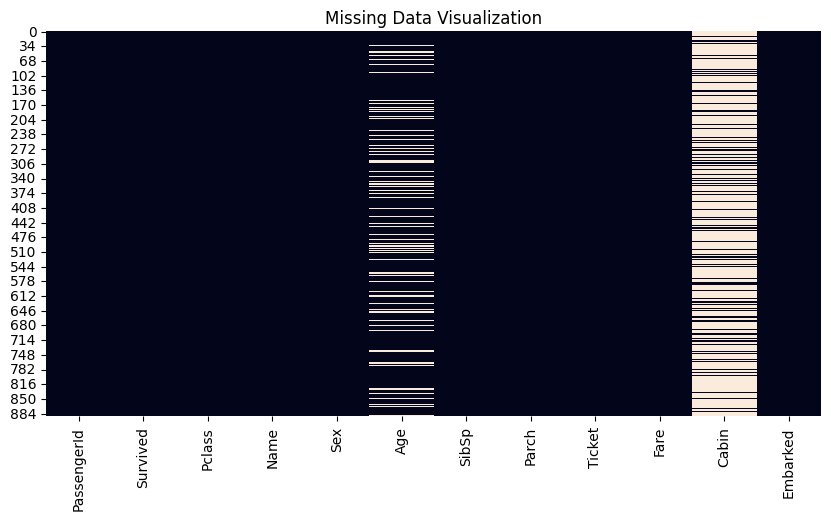

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Visualization")

In [66]:
df = df.drop(["PassengerId","Name","Ticket","Cabin"], axis=1)
df.head()
#remove unnecessary fields

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [67]:
df["Age"] = df["Age"].fillna(df["Age"].median())
"replacing NaN from age col to medium of all vals "

'replacing NaN from age col to medium of all vals '

In [68]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [69]:
df.isnull().sum()
#verify any are there NaN vals

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [70]:
# convert all categorical data to numeric
#Sex
#Embarked
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

In [71]:
df = pd.get_dummies(df, columns=["Embarked"])

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_C  891 non-null    bool   
 8   Embarked_Q  891 non-null    bool   
 9   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(5)
memory usage: 51.5 KB


Text(0.5, 1.0, 'Age Outliers')

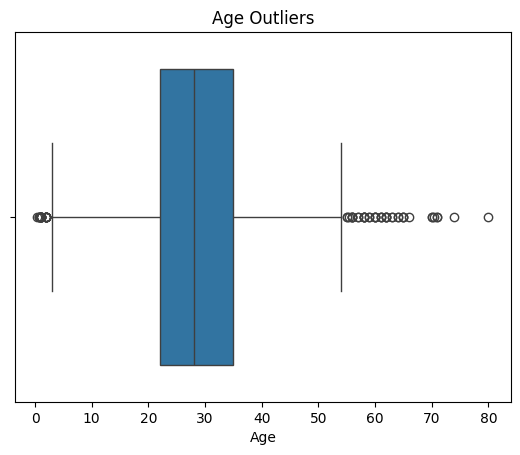

In [73]:
sns.boxplot(x=df["Age"])
plt.title("Age Outliers")

In [74]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

In [75]:
numeric_cols = ["Age","Fare","SibSp","Parch","FamilySize"]

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [77]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [79]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,FamilySize
331,1,0,1.240235,-0.474545,-0.473674,-0.074583,False,False,True,-0.560975
733,2,0,-0.488887,-0.474545,-0.473674,-0.386671,False,False,True,-0.560975
382,3,0,0.202762,-0.474545,-0.473674,-0.488854,False,False,True,-0.560975
704,3,0,-0.258337,0.432793,-0.473674,-0.490280,False,False,True,0.059160
813,3,1,-1.795334,3.154809,2.008933,-0.018709,False,False,True,3.159833


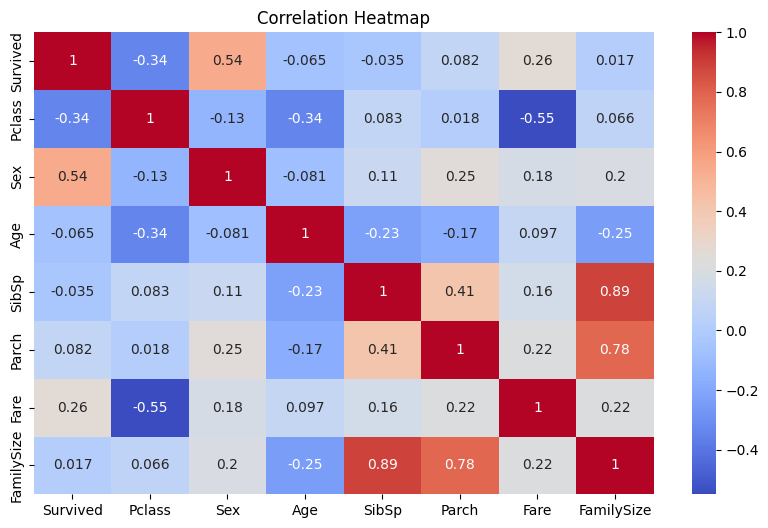

In [80]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Conclusion :
#In this project we performed the following preprocessing steps:
# Data cleaning
# Handling missing values
# Encoding categorical variables
# Outlier detection
# Feature engineering
# Feature scaling
# Train-test split
"""
Raw Data
   ↓
Exploratory Analysis
   ↓
Data Cleaning
   ↓
Missing Value Handling
   ↓
Categorical Encoding
   ↓
Outlier Handling
   ↓
Feature Engineering
   ↓
Feature Scaling
   ↓
Train-Test Split
   ↓
Model-Ready Dataset
"""

In [81]:
# Import function used to split the dataset
from sklearn.model_selection import train_test_split
# Split the dataset into training and testing sets
# X → input features (Age, Fare, Sex, etc.)
# y → target variable (Survived)

X_train, X_test, y_train, y_test = train_test_split(
    X,              # Feature dataset
    y,              # Target variable
    test_size=0.2,  # 20% data used for testing
    random_state=42 # Ensures reproducible results
)

# Display the shape of training and testing datasets
# Shape format: (rows, columns)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (712, 10)
Testing data shape: (179, 10)


In [82]:
# Import StandardScaler for normalization
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# List of numerical columns that need scaling
numeric_cols = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]

# Fit the scaler on training data and transform it
# fit_transform learns mean & std then applies scaling

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Only transform test data using the same scaler
# (Important: never fit test data)

X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

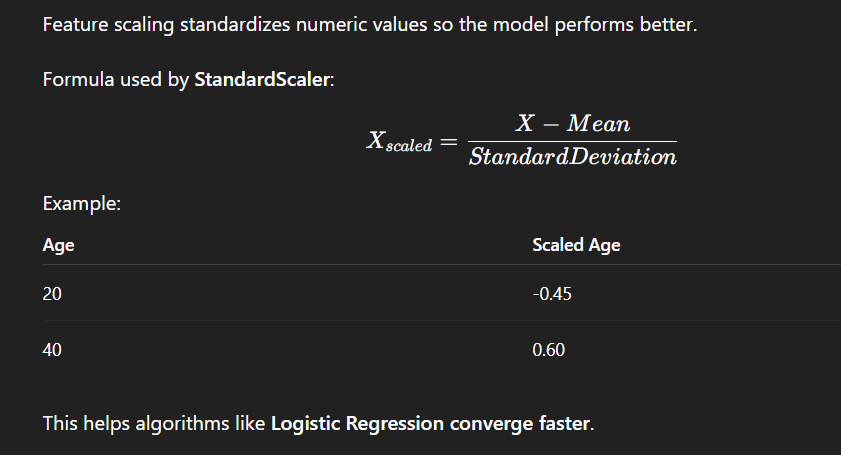

In [83]:
print(X.dtypes)

Pclass          int64
Sex             int64
Age           float64
SibSp         float64
Parch         float64
Fare          float64
Embarked_C       bool
Embarked_Q       bool
Embarked_S       bool
FamilySize    float64
dtype: object


In [84]:
# Import Logistic Regression algorithm
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
# max_iter=1000 increases iterations to ensure convergence

model = LogisticRegression(max_iter=1000)

# Train the model using training data
# The model learns relationships between features and survival

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [85]:
# Predict survival on the test dataset

y_pred = model.predict(X_test)

# Display the first 10 predictions
print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


In [86]:
# Import accuracy metric
from sklearn.metrics import accuracy_score

# Calculate accuracy of predictions

accuracy = accuracy_score(y_test, y_pred)

# Print model accuracy
print("Model Accuracy:", accuracy)

Model Accuracy: 0.8100558659217877


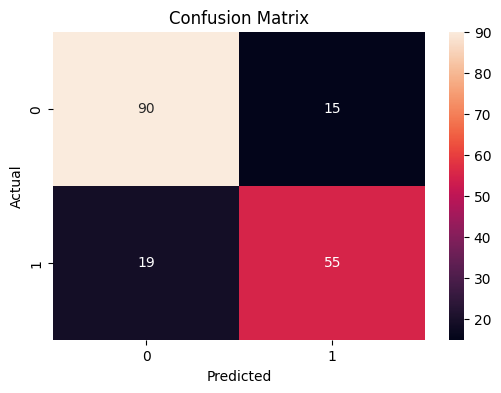

In [87]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap for visualization
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [88]:
# Import classification report
from sklearn.metrics import classification_report

# Print full model performance metrics

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

